Loaded: AnnData object with n_obs × n_vars = 46720 × 3000
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 'n_cells', 'variance', '

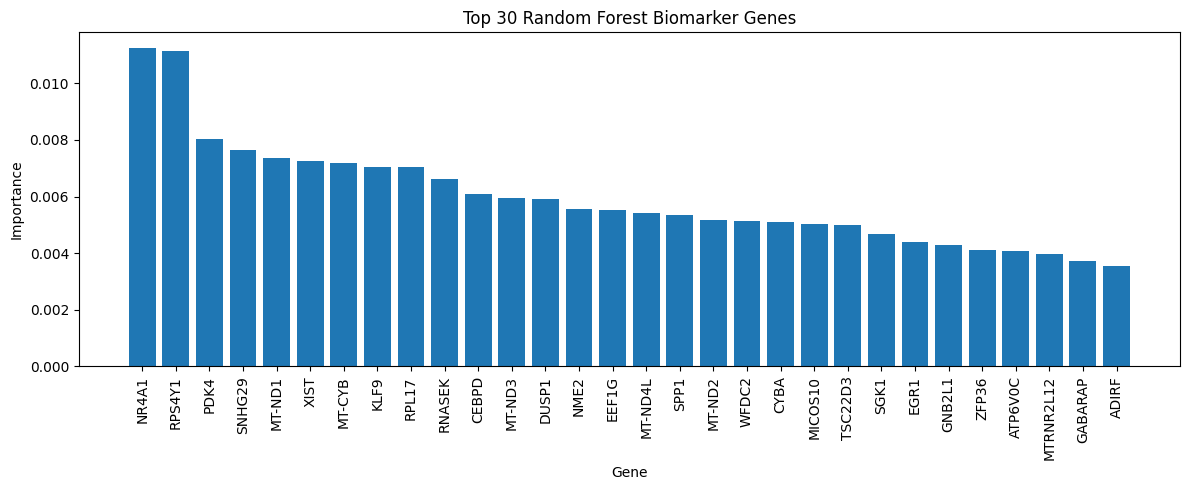


Saved:
- RF_classification_report.txt
- RF_confusion_matrix.csv
- RF_HVG3000_feature_importance.csv
- RF_top100_biomarker_genes.csv
- RF_top30_biomarker_genes.png


In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# =========================================
# Load HVG dataset
# =========================================

adata = sc.read_h5ad(
    RESULTS_DIR / "GSE183276_HVG3000_by_variance.h5ad"
)

print("Loaded:", adata)

# =========================================
# Select labels
# =========================================

label_col = "condition.l1"

print("\n===== Label Distribution =====")
print(
    adata.obs[label_col].value_counts()
)

# remove missing labels
adata = adata[
    ~adata.obs[label_col].isna()
].copy()

# =========================================
# Feature matrix
# =========================================

X = adata.X

if sparse.issparse(X):
    X = X.toarray()

print("\nFeature matrix shape:")
print(X.shape)

# =========================================
# Labels
# =========================================

y = adata.obs[label_col].astype(str)

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("\nClasses:")
print(le.classes_)

# =========================================
# Train/Test split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================================
# Random Forest
# =========================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("\nTraining Random Forest...")

rf.fit(X_train, y_train)

print("Training finished")

# =========================================
# Prediction
# =========================================

y_pred = rf.predict(X_test)

# =========================================
# Metrics
# =========================================

acc = accuracy_score(y_test, y_pred)

print("\n===== Accuracy =====")
print(acc)

print("\n===== Classification Report =====")
report = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
)

print(report)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n===== Confusion Matrix =====")
print(cm)

# save report
with open(
    RESULTS_DIR / "RF_classification_report.txt",
    "w"
) as f:
    f.write(report)

pd.DataFrame(cm).to_csv(
    RESULTS_DIR / "RF_confusion_matrix.csv",
    index=False
)

# =========================================
# Feature Importance
# =========================================

importance_df = pd.DataFrame({
    "gene": adata.var_names,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print("\n===== Top 30 Important Genes =====")
print(
    importance_df.head(30)
)

importance_df.to_csv(
    RESULTS_DIR / "RF_HVG3000_feature_importance.csv",
    index=False
)

# =========================================
# Top biomarker genes
# =========================================

top100 = importance_df.head(100)

top100.to_csv(
    RESULTS_DIR / "RF_top100_biomarker_genes.csv",
    index=False
)

# =========================================
# Plot Top 30 genes
# =========================================

top30 = importance_df.head(30)

plt.figure(figsize=(12,5))

plt.bar(
    top30["gene"],
    top30["importance"]
)

plt.xticks(rotation=90)

plt.xlabel("Gene")
plt.ylabel("Importance")

plt.title("Top 30 Random Forest Biomarker Genes")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "RF_top30_biomarker_genes.png",
    dpi=300
)

plt.show()

# =========================================
# Save trained dataset info
# =========================================

print("\nSaved:")
print("- RF_classification_report.txt")
print("- RF_confusion_matrix.csv")
print("- RF_HVG3000_feature_importance.csv")
print("- RF_top100_biomarker_genes.csv")
print("- RF_top30_biomarker_genes.png")


===== Accuracy =====
0.853595890410959

===== Classification Report =====
              precision    recall  f1-score      support
AKI            0.859196  0.881309  0.870112  4002.000000
CKD            0.826661  0.878536  0.851809  4207.000000
Ref            0.980469  0.663436  0.791382  1135.000000
accuracy       0.853596  0.853596  0.853596     0.853596
macro avg      0.888775  0.807760  0.837768  9344.000000
weighted avg   0.859278  0.853596  0.852308  9344.000000


<Figure size 800x800 with 0 Axes>

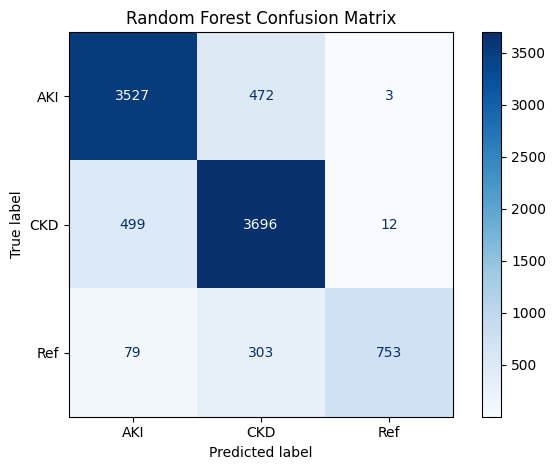

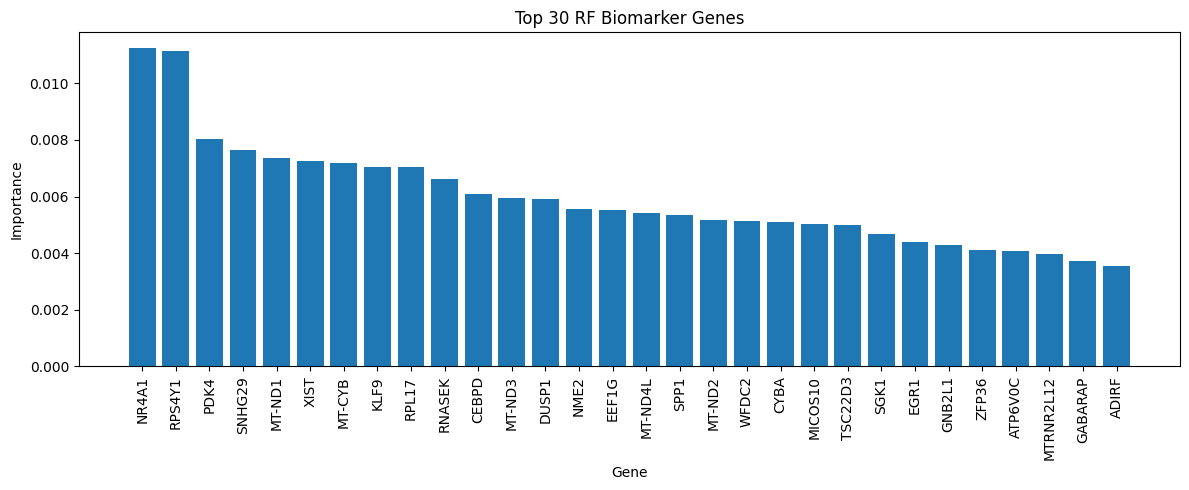

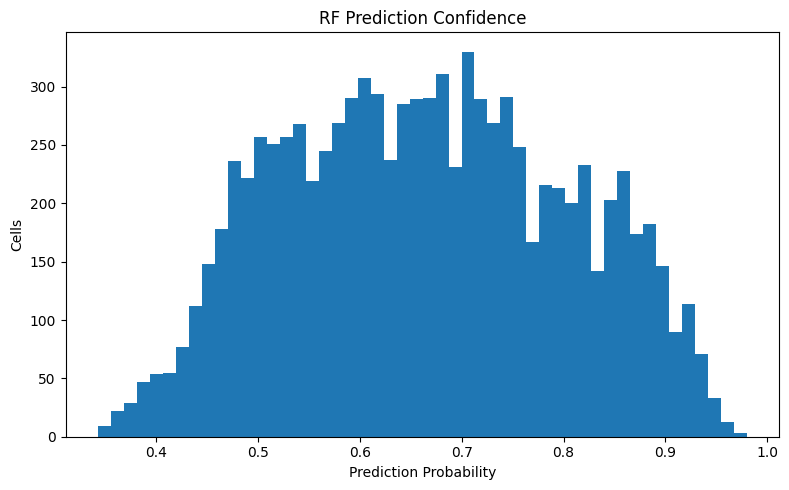

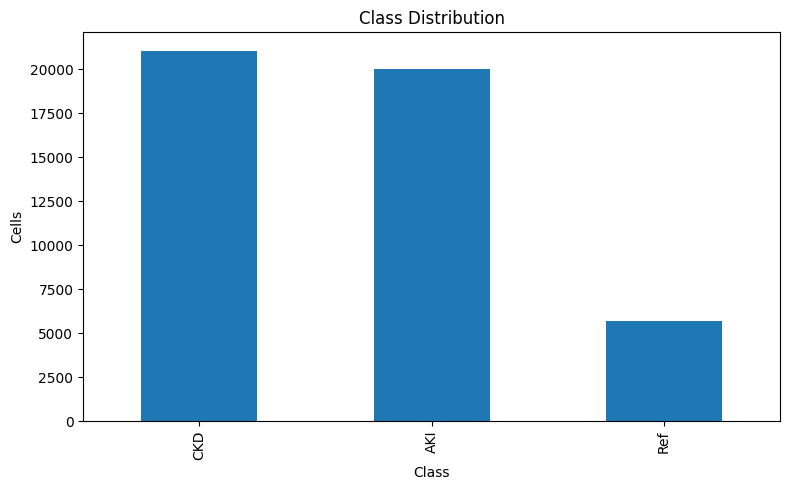

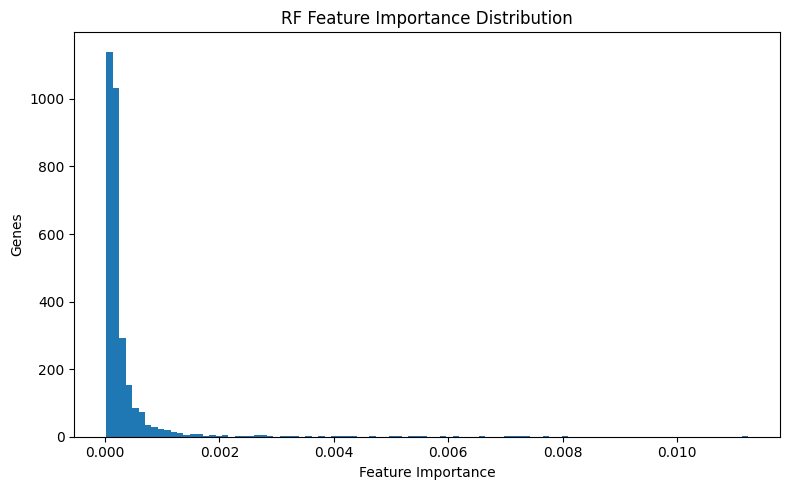


Saved outputs:
- RF_classification_report.csv
- RF_confusion_matrix.csv
- RF_confusion_matrix.png
- RF_feature_importance.csv
- RF_top30_genes.png
- RF_prediction_probability.png
- RF_class_distribution.png
- RF_importance_distribution.png


In [2]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# =========================================
# Load HVG dataset
# =========================================

adata = sc.read_h5ad(
    RESULTS_DIR / "GSE183276_HVG3000_by_variance.h5ad"
)

label_col = "condition.l1"

adata = adata[
    ~adata.obs[label_col].isna()
].copy()

# =========================================
# Features
# =========================================

X = adata.X

if sparse.issparse(X):
    X = X.toarray()

# =========================================
# Labels
# =========================================

y = adata.obs[label_col].astype(str)

le = LabelEncoder()

y_encoded = le.fit_transform(y)

class_names = le.classes_

# =========================================
# Train/Test Split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =========================================
# Train RF
# =========================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# =========================================
# Predictions
# =========================================

y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)

# =========================================
# Accuracy
# =========================================

acc = accuracy_score(y_test, y_pred)

print("\n===== Accuracy =====")
print(acc)

# =========================================
# Classification Report
# =========================================

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\n===== Classification Report =====")
print(report_df)

report_df.to_csv(
    RESULTS_DIR / "RF_classification_report.csv"
)

# =========================================
# Confusion Matrix
# =========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    RESULTS_DIR / "RF_confusion_matrix.csv"
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "RF_confusion_matrix.png",
    dpi=300
)

plt.show()

# =========================================
# Feature Importance
# =========================================

importance_df = pd.DataFrame({
    "gene": adata.var_names,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.to_csv(
    RESULTS_DIR / "RF_feature_importance.csv",
    index=False
)

top30 = importance_df.head(30)

plt.figure(figsize=(12,5))

plt.bar(
    top30["gene"],
    top30["importance"]
)

plt.xticks(rotation=90)

plt.xlabel("Gene")
plt.ylabel("Importance")

plt.title("Top 30 RF Biomarker Genes")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "RF_top30_genes.png",
    dpi=300
)

plt.show()

# =========================================
# Prediction Probability Distribution
# =========================================

max_prob = y_prob.max(axis=1)

plt.figure(figsize=(8,5))

plt.hist(
    max_prob,
    bins=50
)

plt.xlabel("Prediction Probability")
plt.ylabel("Cells")

plt.title("RF Prediction Confidence")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "RF_prediction_probability.png",
    dpi=300
)

plt.show()

# =========================================
# ROC Curve
# =========================================

# binary only
if len(class_names) == 2:

    y_bin = label_binarize(
        y_test,
        classes=np.arange(len(class_names))
    ).ravel()

    fpr, tpr, _ = roc_curve(
        y_bin,
        y_prob[:,1]
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.3f}"
    )

    plt.plot([0,1],[0,1],"--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR / "RF_ROC_curve.png",
        dpi=300
    )

    plt.show()

    print("\nROC AUC:", roc_auc)

# =========================================
# Class Distribution
# =========================================

plt.figure(figsize=(8,5))

pd.Series(y).value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Cells")

plt.title("Class Distribution")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "RF_class_distribution.png",
    dpi=300
)

plt.show()

# =========================================
# Importance Distribution
# =========================================

plt.figure(figsize=(8,5))

plt.hist(
    importance_df["importance"],
    bins=100
)

plt.xlabel("Feature Importance")
plt.ylabel("Genes")

plt.title("RF Feature Importance Distribution")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "RF_importance_distribution.png",
    dpi=300
)

plt.show()

print("\nSaved outputs:")
print("- RF_classification_report.csv")
print("- RF_confusion_matrix.csv")
print("- RF_confusion_matrix.png")
print("- RF_feature_importance.csv")
print("- RF_top30_genes.png")
print("- RF_prediction_probability.png")
print("- RF_class_distribution.png")
print("- RF_importance_distribution.png")